---
1. Native (T1) (raw)
2. Post-contrast T1-weighted (T1CE)
3. T2-weighted (T2)
4. T2 Fluid Attenuated Inversion Recovery (Flair) Volumes

---
### Mask label description
- label 0: unlabeleld
- label 1: necrotic and non-enhancing tumor core
- label 2: peritumoral edema (ED)
- label 3: missing
- label 4: GD-enhancing tumor (ET)
---

In [1]:
import numpy as numpy
import nibabel as nib

import glob
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from sklearn.preprocessing import MinMaxScaler

import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots

from skimage.segmentation import slic
import numpy as np

In [2]:
RAW_DIR = "../data/raw/MICCAI_BraTS2020_TrainingData/"
PROCESSSED_DIR = "../data/processed/"
sample_dir = RAW_DIR + "BraTS20_Training_001/BraTS20_Training_001_flair.nii"

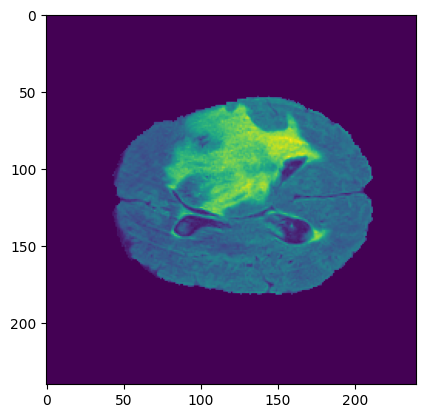

In [3]:
sample_image_raw = nib.load(sample_dir).get_fdata()
sample_image_raw.shape

img = sample_image_raw.reshape(
    -1, 1
)  # reminder: 1-dim is sample, 2-dim is the feature vector
scaler = MinMaxScaler()
img = scaler.fit_transform(img)
sample_image = img.reshape(240, 240, 155)

plt.imshow(sample_image[:, :, 80])

Shape of the image data array: (5, 240, 240, 155)
max: 1091.0, min: 0.0


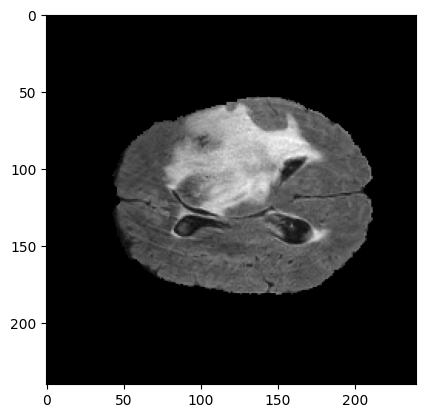

In [4]:
import numpy as np
import os
import nibabel as nib
from sklearn.preprocessing import MinMaxScaler

RAW_DIR = "../data/raw/MICCAI_BraTS2020_TrainingData/"

num_total_samples = 369  # cant allocate memory
num_samples = 5

image_data_list = []

# Iterate over each sample
for i in range(1, num_samples + 1):
    sample_dir = os.path.join(
        RAW_DIR, f"BraTS20_Training_{i:03}", f"BraTS20_Training_{i:03}_flair.nii"
    )
    # print(f"loading img: {i} | directory: {sample_dir}")

    if os.path.exists(sample_dir):
        current_image = nib.load(sample_dir).get_fdata()
        image_data_list.append(current_image)

data_train_raw = np.array(image_data_list)
print("Shape of the image data array:", data_train_raw.shape)
print(f"max: {data_train_raw.max()}, min: {data_train_raw.min()}")
plt.imshow(data_train_raw[0, :, :, 80], cmap="gray")

max: 1.0000000000000009, min: 0.0


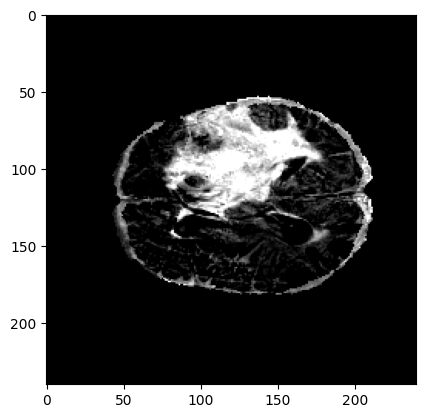

In [5]:
def scale_dataset(dataset):
    scaler = MinMaxScaler()

    data = data_train_raw.reshape(
        num_samples, -1
    )  # reminder: 1-dim is sample, 2-dim is the feature vector
    data = scaler.fit_transform(data)
    data = data.reshape(num_samples, 240, 240, 155)

    return data


data_train = scale_dataset(data_train_raw)
print(f"max: {data_train.max()}, min: {data_train.min()}")
plt.imshow(data_train[0, :, :, 80], cmap="gray")

In [6]:
np.save(PROCESSSED_DIR + " BraTS2020_scaled.npy", data_train)

In [7]:
sample_image.shape

(240, 240, 155)

In [8]:
n_segments = 100

# trade-off between color proximity and spatial proximity
# low: empphasis on color similarity, high: empphasis on proximity
compactness = 0.01

segmented_image = np.zeros_like(sample_image, dtype=np.int32)

segmented_image = slic(
    sample_image, n_segments=n_segments, compactness=compactness, channel_axis=None
)

segmented_image.min(), segmented_image.max(), segmented_image.shape

(1, 54, (240, 240, 155))

In [9]:
sample_image

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [21]:
def plot_slic(segmented_image):
    plt.figure(figsize=(8, 8))
    plt.imshow(segmented_image, cmap="viridis")
    plt.colorbar(label="Segment Labels")
    plt.title("SLIC Segmentation Map")
    plt.xlabel("Width (pixels)")
    plt.ylabel("Height (pixels)")
    plt.grid(False)
    plt.show()

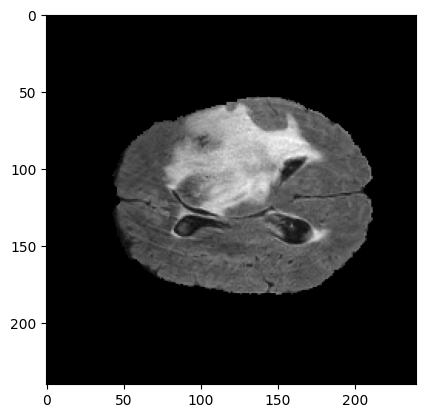

In [13]:
sample_image.shape
plt.imshow(sample_image[:, :, 80], cmap="gray")

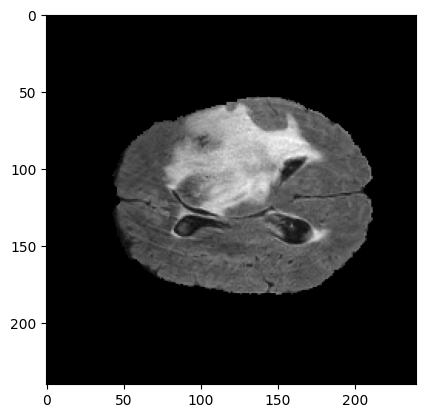

In [15]:
sample_slice = sample_image[:, :, 80]
plt.imshow(sample_slice, cmap="gray")

(240, 240) 1 37


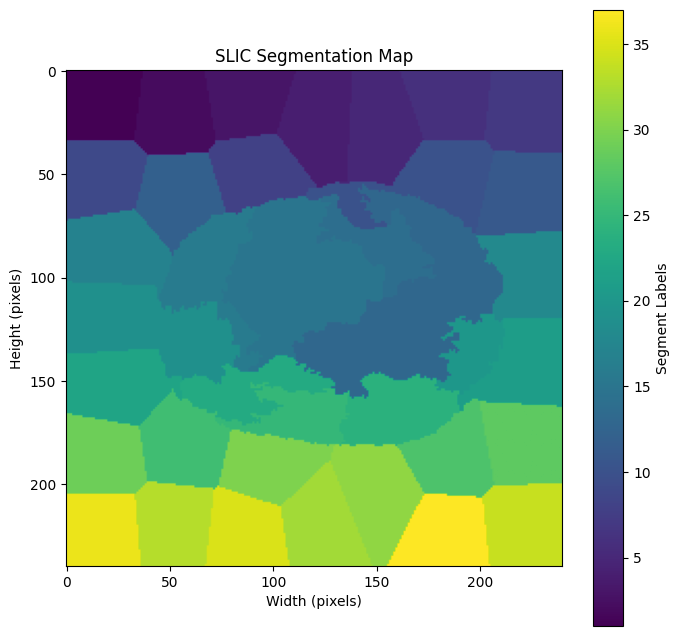

In [33]:
slic_output = slic(sample_slice, n_segments=50, compactness=0.05, channel_axis=None)
print(slic_output.shape, slic_output.min(), slic_output.max())
plot_slic(slic_output)

In [37]:
slic_voxel_result = slic(
    sample_image, n_segments=50, compactness=0.001, channel_axis=None
)

In [39]:
sample_image.shape

(240, 240, 155)

(240, 240, 155) 1 27


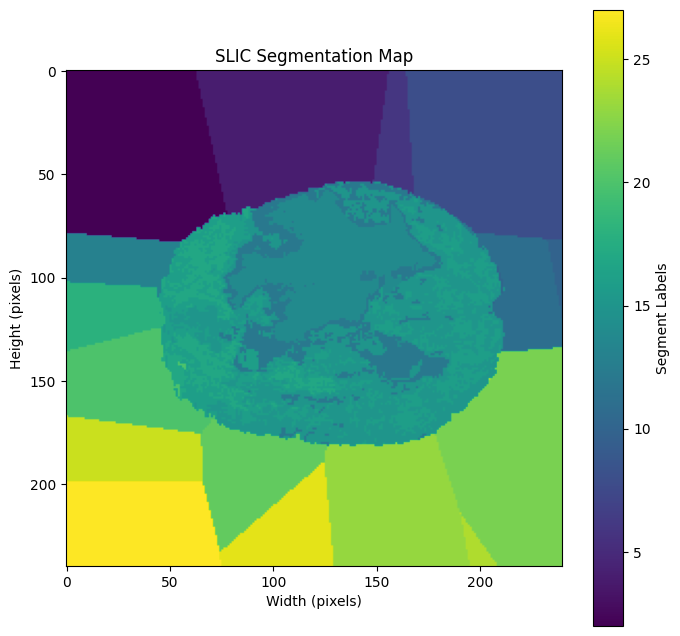

In [40]:
print(slic_voxel_result.shape, slic_voxel_result.min(), slic_voxel_result.max())
plot_slic(slic_voxel_result[:, :, 80])

In [70]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np


class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder layers
        self.encoder_conv1 = nn.Conv3d(1, 8, kernel_size=3, padding=0)
        self.encoder_relu = nn.ReLU(True)
        self.encoder_pool = nn.MaxPool3d(2, padding=0, stride=2)

        # Decoder layers
        self.decoder_conv_transpose = nn.ConvTranspose3d(8, 1, kernel_size=3, stride=2, padding=0, output_padding=(1, 1, 1))
        self.decoder_sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        print(x.shape)
        x = self.encoder_conv1(x)
        print(x.shape)
        x = self.encoder_relu(x)
        print(x.shape)
        x = self.encoder_pool(x)
        print(x.shape)

        # Decoder
        x = self.decoder_conv_transpose(x)
        print(x.shape)
        x = self.decoder_sigmoid(x)
        print(x.shape)

        return x




In [71]:
model = Autoencoder()
model(medical_images_tensor)

torch.Size([1, 1, 240, 240, 155])


: 

In [43]:
sample_image.shape

(240, 240, 155)

In [48]:
medical_images_tensor = (
    torch.tensor(sample_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
)  # add channel dimension
medical_images_tensor.shape

torch.Size([1, 1, 240, 240, 155])

In [58]:
# Create a DataLoader for the dataset
dataset = TensorDataset(medical_images_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Initialize the autoencoder model
autoencoder = Autoencoder()

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

# Training the autoencoder
num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0.0
    for data in dataloader:
        inputs = data[0]

        # Forward pass
        print(inputs.shape)
        outputs = autoencoder(inputs)
        print(outputs.shape)
        loss = criterion(outputs, inputs)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(dataloader)}")

# Save the trained model
torch.save(autoencoder.state_dict(), "autoencoder_model.pth")

torch.Size([1, 1, 240, 240, 155])


torch.Size([1, 1, 240, 240, 154])


ValueError: Using a target size (torch.Size([1, 1, 240, 240, 155])) that is different to the input size (torch.Size([1, 1, 240, 240, 154])) is deprecated. Please ensure they have the same size.